# Micro-Expression Spotting v2 — CASME Dataset (POC-ABS + apex/ module)
Onset–Apex–Offset detection using `apex/` classes (`ApexPhase`, `ApexSmoother`, `ApexPhaseVisualizer`)

### Struktur Dataset CASME
Dataset CASME berisi frame JPG langsung di satu folder (`dataset/casme/*.jpg`),
tanpa hierarki label/subject/question. Seluruh frame dianggap sebagai **satu sesi** tunggal.

### Pipeline
1. **Step 1B** — Salin/index frame JPG dari `ROOT_DIR` → simpan ke output
2. **Step 2B** — Load frame pairs → face detection → ROI → POC-ABS magnitude → simpan `.npy`
3. **Step 3B** — Load magnitudes → adaptive smooth → apex detection → onset/offset → plot

In [1]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import re
import gc

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from features_extraction.poc import POC
from features_extraction.vektor import Vektor
from features_extraction.quadran import Quadran

# apex/ module classes
from apex import ApexPhase, ApexSmoother, ApexPhaseVisualizer

In [2]:
# ======================================================
# CONFIGURATION
# ======================================================
ROOT_DIR = "../dataset/casme"
OUTPUT_DIR = "../output/casme"
FRAMES_DIR_Q = os.path.join(OUTPUT_DIR, "frames_per_q")
MAGNITUDES_DIR_Q = os.path.join(OUTPUT_DIR, "magnitudes_per_q")
PLOTS_DIR_Q = os.path.join(OUTPUT_DIR, "plots_per_q_v2")
PREDICTOR_PATH = "./models/shape_predictor_68_face_landmarks.dat"

BLOCK_SIZE = 7

# ROI definitions (dlib 68-landmark indices)
REGIONS = {
    "mata_kanan":  list(range(42, 48)),
    "mata_kiri":   list(range(36, 42)),
    "alis_kanan":  list(range(22, 27)),
    "alis_kiri":   list(range(17, 22)),
    "mulut":       list(range(48, 68)),
}

TARGET_SIZE = {
    "mata_kanan":  (48, 32),
    "mata_kiri":   (48, 32),
    "alis_kanan":  (48, 20),
    "alis_kiri":   (48, 20),
    "mulut":       (70, 35),
}

PADDING_X = 6
PADDING_Y = 8

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r'(\\d+)', s)]

# Create output dirs
for d in [FRAMES_DIR_Q, MAGNITUDES_DIR_Q, PLOTS_DIR_Q]:
    os.makedirs(d, exist_ok=True)

print("✅ Configuration ready")

✅ Configuration ready


## Step 1B: Prepare Frames (CASME Flat JPG)
CASME dataset berisi frame JPG flat di satu folder.
Step ini meng-index semua frame JPG dari `ROOT_DIR` sebagai satu segment.

In [ ]:
# ======================================================
# STEP 1B: PREPARE FRAMES (CASME flat JPG structure)
# ======================================================
#
# CASME dataset berisi frame JPG langsung di ROOT_DIR:
#   dataset/casme/1.jpg, 2.jpg, 3.jpg, ...
# Semua frame dianggap satu segment tunggal: 'casme_all'

SEGMENT_NAME = "casme_all"
frames_out = os.path.join(FRAMES_DIR_Q, SEGMENT_NAME)

if os.path.isdir(frames_out) and len(os.listdir(frames_out)) > 0:
    print(f"⏩ Skip {SEGMENT_NAME}: frames already prepared")
    q_count = 1
else:
    os.makedirs(frames_out, exist_ok=True)

    # Ambil semua file JPG dari ROOT_DIR, urutkan secara natural (1,2,3,...)
    jpg_files = sorted(
        [f for f in os.listdir(ROOT_DIR) if f.lower().endswith(".jpg")],
        key=natural_sort_key
    )

    if len(jpg_files) == 0:
        print(f"⚠️  Tidak ada file JPG di {ROOT_DIR}")
        q_count = 0
    else:
        # Salin frame ke output dengan naming konsisten frame_00001.jpg dst
        import shutil
        for frame_idx, jpg_name in enumerate(jpg_files):
            src = os.path.join(ROOT_DIR, jpg_name)
            dst = os.path.join(frames_out, f"frame_{frame_idx:05d}.jpg")
            shutil.copy2(src, dst)

        print(f"✅ {SEGMENT_NAME}: {len(jpg_files)} frames prepared")
        q_count = 1

    gc.collect()

print(f"\n🎉 Step 1B done! {q_count} segment processed. Frames in {FRAMES_DIR_Q}/")

## Step 2B: Compute POC-ABS Magnitudes (Per Question)
Load frame pairs, detect face, extract ROIs, compute POC-ABS magnitude, save `.npy`.

In [ ]:
# ======================================================
# STEP 2B: SETUP — Load dlib models + helper functions
# ======================================================

if not os.path.exists(PREDICTOR_PATH):
    raise FileNotFoundError(f"Predictor tidak ditemukan: {PREDICTOR_PATH}")

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)
print("✅ Dlib models loaded")

def extract_region(image, landmarks, indices):
    pts = [(landmarks.part(i).x, landmarks.part(i).y) for i in indices]
    xs, ys = zip(*pts)
    left   = max(0, min(xs) - PADDING_X)
    top    = max(0, min(ys) - PADDING_Y)
    right  = min(image.shape[1], max(xs) + PADDING_X)
    bottom = min(image.shape[0], max(ys) + PADDING_Y)
    return image[top:bottom, left:right]

def detect_landmarks(gray):
    faces = detector(gray)
    if len(faces) > 0:
        return predictor(gray, faces[0])
    return None

def compute_frame_magnitude(prev_gray, prev_lm, curr_gray, curr_lm):
    roi_mags = []
    for region_name, lm_indices in REGIONS.items():
        try:
            roi_prev = extract_region(prev_gray, prev_lm, lm_indices)
            roi_curr = extract_region(curr_gray, curr_lm, lm_indices)

            if roi_prev.size == 0 or roi_curr.size == 0:
                return 0.0

            target = TARGET_SIZE[region_name]
            roi_prev = cv2.resize(roi_prev, target)
            roi_curr = cv2.resize(roi_curr, target)

            poc = POC(roi_prev, roi_curr, BLOCK_SIZE)
            vec = Vektor(poc.getPOC(), BLOCK_SIZE)
            quad_data = Quadran(vec.getVektor()).getQuadran()

            magnitudes = [float(block[4]) for block in quad_data]
            roi_mags.append(np.mean(magnitudes) if magnitudes else 0.0)
        except Exception:
            return 0.0

    return np.mean(roi_mags) if roi_mags else 0.0

In [ ]:
# ======================================================
# STEP 2B: COMPUTE MAGNITUDES (Per Question)
# ======================================================

q_count = 0

for q_folder in sorted(os.listdir(FRAMES_DIR_Q), key=natural_sort_key):
    q_frames_dir = os.path.join(FRAMES_DIR_Q, q_folder)
    if not os.path.isdir(q_frames_dir):
        continue

    npy_path = os.path.join(MAGNITUDES_DIR_Q, f"{q_folder}.npy")

    if os.path.exists(npy_path):
        print(f"⏩ Skip {q_folder}: magnitudes already computed")
        q_count += 1
        continue

    frame_files = sorted(
        [f for f in os.listdir(q_frames_dir) if f.endswith(".jpg")],
        key=natural_sort_key
    )

    if len(frame_files) < 3:
        print(f"⚠️  Skip {q_folder}: too few frames ({len(frame_files)})")
        continue

    print(f"🔄 Processing {q_folder} ({len(frame_files)} frames)...")

    magnitude_list = []

    prev_gray = cv2.imread(os.path.join(q_frames_dir, frame_files[0]), cv2.IMREAD_GRAYSCALE)
    prev_lm = detect_landmarks(prev_gray)

    for i in range(1, len(frame_files)):
        curr_gray = cv2.imread(os.path.join(q_frames_dir, frame_files[i]), cv2.IMREAD_GRAYSCALE)
        curr_lm = detect_landmarks(curr_gray)

        if prev_lm is not None and curr_lm is not None:
            mag = compute_frame_magnitude(prev_gray, prev_lm, curr_gray, curr_lm)
        else:
            mag = 0.0

        magnitude_list.append(mag)
        prev_gray = curr_gray
        prev_lm = curr_lm

    np.save(npy_path, np.array(magnitude_list, dtype=float))
    print(f"✅ {q_folder}: {len(magnitude_list)} magnitudes saved")
    q_count += 1
    gc.collect()

print(f"\n🎉 Step 2B done! {q_count} segments processed. Magnitudes in {MAGNITUDES_DIR_Q}/")

## Step 3B: Analyze & Visualize (Per Question) — Using `apex/` Module
Uses `ApexSmoother` for adaptive window, `ApexPhase` for peak + phase detection, `ApexPhaseVisualizer` for plotting.

🔍 casme | frames=835 | window=31 | polyorder=4
  ✅ Apex: 179 | Onset: 166 | Offset: 187 | Duration: 21
  ✅ Apex: 268 | Onset: 264 | Offset: 276 | Duration: 12
  ✅ Apex: 289 | Onset: 285 | Offset: 295 | Duration: 10
  ✅ Apex: 333 | Onset: 329 | Offset: 339 | Duration: 10
  ✅ Apex: 358 | Onset: 353 | Offset: 375 | Duration: 22
  ✅ Apex: 411 | Onset: 397 | Offset: 416 | Duration: 19
  ✅ Apex: 433 | Onset: 429 | Offset: 438 | Duration: 9
  ✅ Apex: 455 | Onset: 452 | Offset: 459 | Duration: 7
  ✅ Apex: 466 | Onset: 460 | Offset: 473 | Duration: 13
  ✅ Apex: 490 | Onset: 484 | Offset: 500 | Duration: 16
  ✅ Apex: 512 | Onset: 507 | Offset: 516 | Duration: 9
  ✅ Apex: 532 | Onset: 522 | Offset: 539 | Duration: 17
  ✅ Apex: 587 | Onset: 572 | Offset: 592 | Duration: 20
  ✅ Apex: 597 | Onset: 595 | Offset: 602 | Duration: 7
  ✅ Apex: 631 | Onset: 617 | Offset: 636 | Duration: 19
  ✅ Apex: 686 | Onset: 682 | Offset: 692 | Duration: 10
  ✅ Apex: 708 | Onset: 699 | Offset: 714 | Duration: 15
  ✅ A

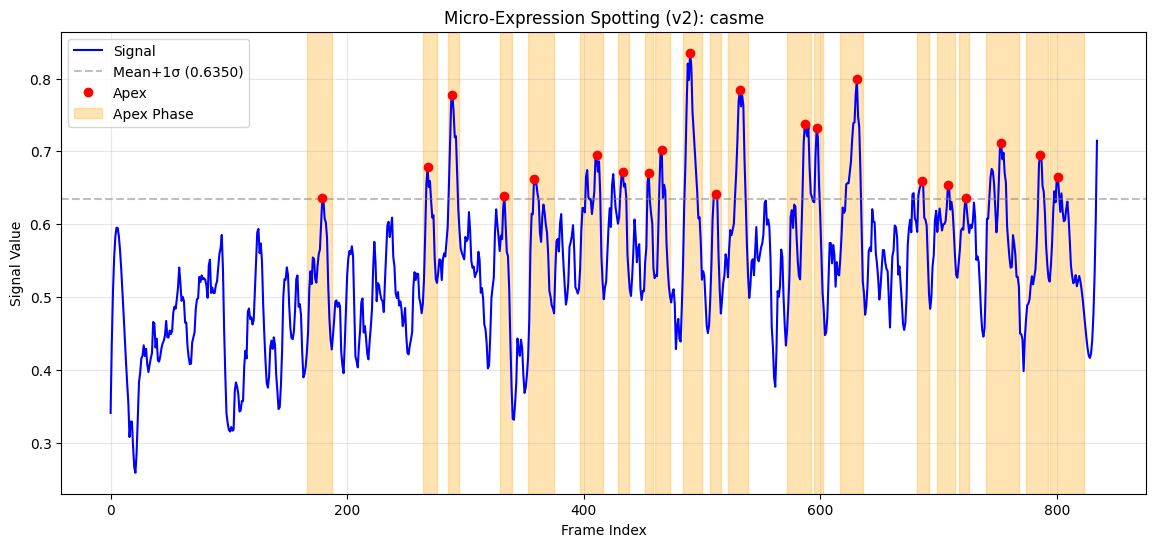


🎉 Step 3B done! Plots saved to ../output/casme/plots_per_q_v2/


In [4]:
# ======================================================
# STEP 3B: ANALYZE & VISUALIZE (Per Question) — apex/ module
# ======================================================

# Micro-expression duration filter — hanya filter noise (durasi < MIN)
# Tidak ada batas atas agar tidak membuang micro-expression yang valid
MIN_PHASE_DURATION = 2  # frame minimum (hindari noise 0-1 frame)

# Initialize apex module classes
apex_detector = ApexPhase(
    distance_threshold=1,
    prominence_threshold=0.005,
    cutoff_ratio=0.3
)
visualizer = ApexPhaseVisualizer()

# Accumulator untuk summary statistics
all_stats = []

for npy_file in sorted(os.listdir(MAGNITUDES_DIR_Q)):
    if not npy_file.endswith(".npy"):
        continue

    q_name = os.path.splitext(npy_file)[0]
    mag_path = os.path.join(MAGNITUDES_DIR_Q, npy_file)
    raw_magnitudes = np.load(mag_path).tolist()

    # --- Adaptive Smoothing (ApexSmoother.smooth) ---
    try:
        smoothed = ApexSmoother.smooth(raw_magnitudes)
    except ValueError as e:
        print(f"⚠️ Skip {q_name}: {e}")
        continue

    wl = ApexSmoother.calculate_window_length(len(raw_magnitudes))
    po = ApexSmoother.calculate_polyorder(wl)
    print(f"🔍 {q_name} | frames={len(raw_magnitudes)} | window={wl} | polyorder={po}")

    # --- Apex Detection (with height threshold: mean + 1*std) ---
    signal_arr = np.array(smoothed)
    height_threshold = float(np.mean(signal_arr) + np.std(signal_arr))
    apex_indices = apex_detector.find_top_k_apex(smoothed, k=0, height=height_threshold)

    if len(apex_indices) == 0:
        print(f"  ⚠️ No apex detected above threshold ({height_threshold:.4f})")
        all_stats.append(dict(name=q_name, total_frames=len(raw_magnitudes), apex_count=0, phases=[]))
        continue

    # --- Phase Detection (onset/offset) ---
    phases = apex_detector.find_phase(smoothed, apex_indices)

    # --- Filter: hanya buang micro-noise (durasi sangat pendek) ---
    filtered_apex = []
    filtered_phases = {}
    for apex_idx in apex_indices:
        phase = phases[apex_idx]
        duration = phase['end'] - phase['start']
        if duration >= MIN_PHASE_DURATION:
            filtered_apex.append(apex_idx)
            filtered_phases[apex_idx] = phase
            print(f"  ✅ Apex: {apex_idx} | Onset: {phase['start']} | Offset: {phase['end']} | Duration: {duration}")
        else:
            print(f"  ❌ Apex: {apex_idx} | Duration: {duration} (filtered out, terlalu pendek < {MIN_PHASE_DURATION})")

    # Collect stats
    phase_durations = [filtered_phases[a]['end'] - filtered_phases[a]['start'] for a in filtered_apex]
    all_stats.append(dict(
        name=q_name,
        total_frames=len(raw_magnitudes),
        apex_count=len(filtered_apex),
        phases=phase_durations
    ))

    # --- Visualize ---
    if len(filtered_apex) > 0:
        save_path = os.path.join(PLOTS_DIR_Q, f"{q_name}.png")
        visualizer.plot_phases(
            signal=smoothed,
            apex_indices=filtered_apex,
            phases=filtered_phases,
            title=f"Micro-Expression Spotting (v2): {q_name}",
            save_path=save_path
        )
    else:
        print(f"  ⚠️ No valid phases after filtering")

print(f"\n🎉 Step 3B done! Plots saved to {PLOTS_DIR_Q}/")